In [1]:
import IPython.display as ipd

import os, sys
current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1]) +"/"
sys.path.insert(0,homepath)

# import pandas as pd
# import matplotlib.pyplot as plt
# import reciprocalspaceship as rs
# from occupancy import *
# from plotting3d import *
%load_ext autoreload 
%autoreload 2


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import reciprocalspaceship as rs
import pandas as pd
from meteor import rsmap
from meteor.utils import cut_resolution

from logger import setup_logger

logger = setup_logger()
from meteor.diffmaps import (
    compute_difference_map,
    max_negentropy_kweighted_difference_map,
)
# from systematic_plots import get_fits2
# from systematic_plots import load_defaults, calculate_scaled_maps, cut_resolution

# from meteor.tv import tv_denoise_difference_map
# from meteor.validate import map_negentropy

In [ ]:
from unittest import case
import gemmi
from meteor.sfcalc import gemmi_structure_to_calculated_map
from meteor.scale import scale_maps
from processing import get_meta_loc
# from meteorize import get_meta_loc
# from meteorize import calculate_diffmaps
# from meteorize import load_homepath
from configuration import load_homepath
homepath = load_homepath()
folderloc = homepath + "data/esther/"
version = {"10ns": dict(
            fname = "esther_10ns",
            dataloc_dark = folderloc + "mmCPD_zeroDTT_dark_no-glovebox_dark.mtz",
            dataloc_light = folderloc + "mmCPD_zeroDTT_10ns_21ph-xsection_light.mtz",
        ),
         "10us": dict(
            fname = "esther_10us",
            dataloc_dark = folderloc + "mmCPD_zeroDTT_dark_no-glovebox_dark.mtz",
            dataloc_light = folderloc + "mmCPD_zeroDTT_10us_21ph-xsection_light.mtz",
        ),
         "300ps": dict(
            fname = "esther_300ps",
            dataloc_dark = folderloc + "mmCPD_zeroDTT_dark_no-glovebox_dark.mtz",
            dataloc_light = folderloc + "mmCPD_zeroDTT_300ps_21ph-xsection_light.mtz"
        ),
         "300fs": dict(
            fname = "esther_300fs",
            dataloc_dark = folderloc + "mmCPD_zeroDTT_dark_glovebox_dark.mtz",
            dataloc_light = folderloc + "mmCPD_zeroDTT_300fs_9p4ph-xsection_light.mtz"
        )
    }
version = {"10ns": dict(
            fname = "esther_10ns",
            dataloc_dark = folderloc + "mmCPD_zeroDTT_dark_no-glovebox_dark.mtz",
            dataloc_light = folderloc + "mmCPD_zeroDTT_10ns_21ph-xsection_light.mtz",
            diffmap_loc = folderloc + "mmCPD_zeroDTT_10ns_21ph-xsection_light_mqFoFo.mtz",
        ),
         "10us": dict(
            fname = "esther_10us",
            dataloc_dark = folderloc + "mmCPD_zeroDTT_dark_no-glovebox_dark.mtz",
            dataloc_light = folderloc + "mmCPD_zeroDTT_10us_21ph-xsection_light.mtz",
            diffmap_loc = folderloc + "mmCPD_zeroDTT_10us_21ph-xsection_light_mqFoFo.mtz"
        ),
         "300ps": dict(
            fname = "esther_300ps",
            dataloc_dark = folderloc + "mmCPD_zeroDTT_dark_no-glovebox_dark.mtz",
            dataloc_light = folderloc + "mmCPD_zeroDTT_300ps_21ph-xsection_light.mtz"
        ),
         "300fs": dict(
            fname = "esther_300fs",
            dataloc_dark = folderloc + "mmCPD_zeroDTT_dark_glovebox_dark.mtz",
            dataloc_light = folderloc + "mmCPD_zeroDTT_300fs_9p4ph-xsection_light.mtz"
        )
    }

def make_map(dataloc, map_dark_comp, columns):
    ds = rs.read_mtz(dataloc)
    ds["F"] = np.sqrt(np.abs(ds["I"]))*np.sign(ds["I"])
    ds["SIGF"] = np.sqrt(ds["SIGI"]/(2*np.abs(ds["I"])))
    ds["PHIC"] = map_dark_comp.phases
    rmap = rsmap.Map(ds, **columns)
    rmap.canonicalize_amplitudes()
    rmap = scale_maps(reference_map=map_dark_comp, map_to_scale=rmap)
    return rmap


/Users/sbielfel/Nextcloud2/time_resolved/data/esther/X3S1_dark.pdb


2026-03-02 21:38:09,681: logger: INFO: this is calculate_again False (processing.py:96)


2026-03-02 21:38:10 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-03-02 21:38:10 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-03-02 21:38:10 [info     ] Computing difference map.     
2026-03-02 21:38:37 [info     ]   using negentropy max.        kparameter=0.42
2026-03-02 21:38:37 [info     ] Searching for max-negentropy TV denoising weight method='golden-section search'
2026-03-02 21:38:37 [info     ] This may take some time...    
2026-03-02 21:39:08 [info     ] Optimal TV weight found        final_negentropy=5.43e-02 initial_negentropy=-2.22e-04 weight=9.86e-03


2026-03-02 21:39:08,336: logger: INFO: diffmap has uncertainties: True (processing.py:159)
2026-03-02 21:39:08,437: logger: INFO: ignore_mask voxel count: 0.48279513888888886 (processing.py:219)
2026-03-02 21:39:08,447: logger: INFO: Shift value 0.40818 corresponds to zero frequency 222435.406 (processing.py:233)
2026-03-02 21:39:08,532: logger: INFO: ignore_mask voxel count: 0.6214232494212963 (processing.py:219)
2026-03-02 21:39:08,545: logger: INFO: Shift value 0.41098 corresponds to zero frequency 223963.594 (processing.py:233)


In [37]:

from processing import autoshift_rsmap, autoshift_rsmap_old, combined_diffmap_calc
def calc_maps( 
    dmin=1.8,
    variant="300fs",
):
    fname = version[variant]["fname"]
    dataloc_dark = version[variant]["dataloc_dark"]
    dataloc_light = version[variant]["dataloc_light"]
    pdbloc_dark = folderloc + "X3S1_dark.pdb"
    dark_columns = dict(
        amplitude_column="F",
        phase_column="PHIC",
        uncertainty_column="SIGF",
    )
    light_columns = dict(
        amplitude_column="F",
        phase_column="PHIC",
        uncertainty_column="SIGF",
    )
    info_container = {
        "dataloc_dark": dataloc_dark,
        "dataloc_light": dataloc_light,
        "pdbloc_dark": pdbloc_dark,
        "dark_columns": dark_columns,
        "light_columns": light_columns,
        "dark_cols": dark_columns,
        "light_cols": light_columns,
        "datatype": "ECH",
        "fname": fname,
        "tname": fname,
        "fshort": fname,
        "dark_phases": True,
        "FreeR_col": "R-free-flags",
        "map_sampling": 3,
        "name_machine": fname
    }
    info_container["hs_limit"] = dmin
    struc = gemmi.read_pdb(info_container["pdbloc_dark"])
    print(info_container["pdbloc_dark"])
    map_dark_comp = gemmi_structure_to_calculated_map(
        struc, high_resolution_limit=info_container["hs_limit"]
    )
    info_container["high_resolution_limit"] = info_container["hs_limit"]
    map_dark = make_map(dataloc_dark, map_dark_comp, dark_columns)
    map_light = make_map(dataloc_light, map_dark_comp, light_columns)
    map_light.cell = map_dark.cell
    map_dark = cut_resolution(map_dark, high_resolution_limit=dmin)
    map_light = cut_resolution(map_light, high_resolution_limit=dmin)
    if True:
        diffmap_temp = combined_diffmap_calc(
                map_dark,
                map_light,
                map_dark_comp,
                diffmap_type="tv",
                general_config=info_container,
            )
        diffmap_temp_np = diffmap_temp.to_3d_numpy_map(
                map_sampling=3,
            )
        diffmap_larger = np.abs(diffmap_temp_np) > 1 * diffmap_temp_np.std()

        map_dark,_  = autoshift_rsmap_old(map_dark, info_container, map_dark_comp)
        map_light, _ = autoshift_rsmap_old(map_light, info_container, map_dark_comp, diffmap_larger)
    else:
        map_dark, _ = autoshift_rsmap(map_dark, info_container, map_dark_comp)
        map_light, _ = autoshift_rsmap(map_light, info_container, map_dark_comp)
    return info_container, map_dark, map_light, map_dark_comp
# info_container, map_dark, map_light, map_dark_comp = calc_maps()


In [34]:
def calc_diffmap(map_dark, map_light, map_dark_comp, info_container, parameters):
    meta_loc = get_meta_loc(info_container)

    if parameters.get("get_kweighted", False):
        diffmap = calculate_diffmaps(
            map_dark, map_light, map_dark_comp, meta_loc, only_kweighted=True
        )
    elif parameters.get("get_tv", False):
        diffmap = calculate_diffmaps(
            map_dark, map_light, map_dark_comp, meta_loc, only_kweighted=False, 
        )
    elif parameters.get("tv_weight", False):
        print("Using provided TV weight and K weight to calculate diffmap")
        diffmap = calculate_diffmaps(
            map_dark, map_light, map_dark_comp, meta_loc, parameters=parameters
        )

    else:
        diffmap = compute_difference_map(derivative=map_light, native=map_dark)

    return diffmap

In [38]:
plt.close("all")
%matplotlib inline
# from background_matching import plot_simple
from processing import combined_diffmap_calc
from estimation import plot_extrapolation_estimate_v2, plot_extrapolation_estimate
from masking import make_inclusion_mask
from configuration import get_file_config
parameters = dict(get_tv=True, get_kweighted=False, tv_weight=2.73e-2, k_weight=0.18)
parameters= parameters | dict(
    min_blob_size=4,
    blocking_radius = 1.1,
    sigma=3,
    shift_dark_mean=0,
)
print(parameters)

collect = []
for variant in version.keys():
# for variant in ["300ps", "300fs"]:
    if variant == "300fs":
        continue
    tup = calc_maps(
        dmin=1.8,
        variant=variant,
    )

    info_container, map_dark, map_light, map_dark_comp = tup
    config = get_file_config(
        dataloc_dark=info_container["dataloc_dark"],
        dataloc_light=info_container["dataloc_light"],
        pdbloc_dark=info_container["pdbloc_dark"],
        columns_dark=info_container["dark_columns"],
        columns_triggered=info_container["light_columns"],
        name_machine=info_container["fname"],
        name_human=info_container["tname"],
        high_resolution_limit=info_container["hs_limit"],
        )
    if variant == "300ps":
        config["masking"]['dark_size_threshold'] = 0.08
    elif variant == "300fs":
        config["masking"]['dark_size_threshold'] = 0.1
    else:
        config["masking"]['dark_size_threshold'] = 0.001
    diffmap = combined_diffmap_calc(map_dark, map_light, map_dark_comp, diffmap_type="tv", general_config=config['general'])
    collect.append((variant, config, map_dark,  diffmap))
    inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)
    plot_extrapolation_estimate_v2(diffmap, map_dark, inclusion_mask,config)
    plt.suptitle(f"Variant: {variant}")
    plt.ylim(0,.3)
    plt.show()

# plot_overview( diffmap, map_dark, info_container, parameters)


{'get_tv': True, 'get_kweighted': False, 'tv_weight': 0.0273, 'k_weight': 0.18, 'min_blob_size': 4, 'blocking_radius': 1.1, 'sigma': 3, 'shift_dark_mean': 0}
/Users/sbielfel/Nextcloud2/time_resolved/data/esther/X3S1_dark.pdb


2026-03-02 21:41:39,203: logger: INFO: this is calculate_again False (processing.py:96)


2026-03-02 21:41:39 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-03-02 21:41:40 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-03-02 21:41:40 [info     ] Computing difference map.     
2026-03-02 21:42:07 [info     ]   using negentropy max.        kparameter=0.0
2026-03-02 21:42:07 [info     ] Searching for max-negentropy TV denoising weight method='golden-section search'
2026-03-02 21:42:07 [info     ] This may take some time...    
2026-03-02 21:42:39 [info     ] Optimal TV weight found        final_negentropy=2.22e-02 initial_negentropy=-1.80e-04 weight=1.26e-02


2026-03-02 21:42:39,486: logger: INFO: diffmap has uncertainties: True (processing.py:159)
2026-03-02 21:42:39,587: logger: INFO: ignore_mask voxel count: 0.48279513888888886 (processing.py:219)
2026-03-02 21:42:39,598: logger: INFO: Shift value 0.40814 corresponds to zero frequency 222417.297 (processing.py:233)
2026-03-02 21:42:39,684: logger: INFO: ignore_mask voxel count: 0.6291767939814815 (processing.py:219)
2026-03-02 21:42:39,696: logger: INFO: Shift value 0.40708 corresponds to zero frequency 221841.047 (processing.py:233)
2026-03-02 21:42:39,711: logger: INFO: this is calculate_again True (processing.py:96)
2026-03-02 21:42:39,712: logger: INFO: loading: 0.0, tv_weight: 0.012604598337512585, only_kweighted: False (processing.py:117)


2026-03-02 21:42:40 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-03-02 21:42:40 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-03-02 21:42:40 [info     ] Computing difference map.     
2026-03-02 21:42:40 [info     ]   using fixed                  kparameter=0.0
2026-03-02 21:42:40 [info     ] TV denoising with fixed weight weight=0.012604598337512585


ValueError: column H of type int64 cannot be written to an MTZ file. To skip columns without explicit MTZ dtypes, set skip_problem_mtztypes=True

In [7]:
def make_folder_name(general_config, diffmap_type=""):
    folder = load_homepath() + f"xtr_map_overview/{general_config['name_machine']}/"
    os.makedirs(folder, exist_ok=True)
    parameters = dict()
    parameters["folder"] = folder
    parameters["xtr_prefix"] = general_config["name_machine"] + f"_{diffmap_type}"
    parameters["diffmap_prefix"] = info_container["fname"] + f"_{diffmap_type}_diff.mtz"
    return parameters


In [8]:
config


{'general': {'name_human': 'esther_300ps',
  'name_machine': 'esther_300ps',
  'output_base_folder': '.',
  'map_sampling': 3,
  'high_resolution_limit': 1.8,
  'output_folder': './esther_300ps/',
  'pdbloc_dark': '/Users/sbielfel/Nextcloud2/time_resolved/data/esther/X3S1_dark.pdb'},
 'input_files': {'map_dark': '/Users/sbielfel/Nextcloud2/time_resolved/data/esther/mmCPD_zeroDTT_dark_no-glovebox_dark.mtz',
  'map_triggered': '/Users/sbielfel/Nextcloud2/time_resolved/data/esther/mmCPD_zeroDTT_300ps_21ph-xsection_light.mtz',
  'pdb_dark': '/Users/sbielfel/Nextcloud2/time_resolved/data/esther/X3S1_dark.pdb',
  'columns_dark': {'amplitude_column': 'F',
   'phase_column': 'PHIC',
   'uncertainty_column': 'SIGF'},
  'columns_triggered': {'amplitude_column': 'F',
   'phase_column': 'PHIC',
   'uncertainty_column': 'SIGF'},
  'impose_dark_phases': True},
 'masking': {'sigma': 3,
  'min_blob_size': 3,
  'blocking_radius': 1.5,
  'blocking_percentile': 95,
  'exclude_solvent': True,
  'dark_size

In [9]:
# tup = calc_maps(
#     dmin=1.8,
#     variant=variant,
# )
# info_container, map_dark, map_light, map_dark_comp = tup
# config = get_file_config(
#     dataloc_dark=info_container["dataloc_dark"],
#     dataloc_light=info_container["dataloc_light"],
#     pdbloc_dark=info_container["pdbloc_dark"],
#     columns_dark=info_container["dark_columns"],
#     columns_triggered=info_container["light_columns"],
#     name_machine=info_container["fname"],
#     name_human=info_container["tname"],
#     high_resolution_limit=info_container["hs_limit"],
#     )
# config["masking"]['dark_size_threshold'] = 0.2
# diffmap = combined_diffmap_calc(map_dark, map_light, map_dark_comp, diffmap_type="tv", general_config=config['general'])
# collect.append((variant, info_container, map_dark,  diffmap))
# inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)
# plot_extrapolation_estimate_v2(diffmap, map_dark, inclusion_mask,config)
# plt.suptitle(f"Variant: {variant}")
# plt.ylim(0,.3)
# plt.show()

# # plot_overview( diffmap, map_dark, info_container, parameters)



In [10]:
from xtr_maps import save_extrapolated_map, save_to_folder
save_for = {
    "300fs": dict( most_plausible=0.08,
    ),
    "300ps": dict( implausible_largest=0.2,
                  hopes_and_dreams=0.05,
    ),
    "10us": dict(estimate_largest = 0.17,
                estiamte_most = 0.1,
    ),
    "10ns": dict( very_difficult=0.05)
}
for tup in collect:
    variant, config, map_dark, diffmap = tup
    parameters = make_folder_name(config['general'], diffmap_type="tv")
    save_dict = save_for[variant]
    save_to_folder(diffmap, map_dark, parameters, config["input_files"], save_dict)

2026-03-02 21:27:16,632: logger: INFO: Ensured folder exists: /Users/sbielfel/Nextcloud2/time_resolved/xtr_map_overview/esther_10ns (xtr_maps.py:103)


2026-03-02 21:27:16,634: logger: WARNING: pdb_triggered not found in info_container, skipping copy. (xtr_maps.py:110)
2026-03-02 21:27:16,634: logger: WARNING: pdb_triggered not found in info_container, skipping copy: 'pdb_triggered' (xtr_maps.py:118)
2026-03-02 21:27:16,712: logger: INFO: Columns of xtr: Index(['F', 'PHI', 'SIGF'], dtype='object') (xtr_maps.py:56)
2026-03-02 21:27:16,729: logger: INFO: Ensured folder exists: /Users/sbielfel/Nextcloud2/time_resolved/xtr_map_overview/esther_10us (xtr_maps.py:103)
2026-03-02 21:27:16,731: logger: WARNING: pdb_triggered not found in info_container, skipping copy. (xtr_maps.py:110)
2026-03-02 21:27:16,731: logger: WARNING: pdb_triggered not found in info_container, skipping copy: 'pdb_triggered' (xtr_maps.py:118)
2026-03-02 21:27:16,773: logger: INFO: Columns of xtr: Index(['F', 'PHI', 'SIGF'], dtype='object') (xtr_maps.py:56)
2026-03-02 21:27:16,818: logger: INFO: Columns of xtr: Index(['F', 'PHI', 'SIGF'], dtype='object') (xtr_maps.py:56

Absolute folder path: /Users/sbielfel/Nextcloud2/time_resolved/xtr_map_overview/esther_10ns
Checking for 
pdb_dark copying to /Users/sbielfel/Nextcloud2/time_resolved/xtr_map_overview/esther_10ns...
Checking for 
pdb_triggered copying to /Users/sbielfel/Nextcloud2/time_resolved/xtr_map_overview/esther_10ns...
Checking for 
map_dark copying to /Users/sbielfel/Nextcloud2/time_resolved/xtr_map_overview/esther_10ns...
Checking for 
map_triggered copying to /Users/sbielfel/Nextcloud2/time_resolved/xtr_map_overview/esther_10ns...
Absolute folder path: /Users/sbielfel/Nextcloud2/time_resolved/xtr_map_overview/esther_10us
Checking for 
pdb_dark copying to /Users/sbielfel/Nextcloud2/time_resolved/xtr_map_overview/esther_10us...
Checking for 
pdb_triggered copying to /Users/sbielfel/Nextcloud2/time_resolved/xtr_map_overview/esther_10us...
Checking for 
map_dark copying to /Users/sbielfel/Nextcloud2/time_resolved/xtr_map_overview/esther_10us...
Checking for 
map_triggered copying to /Users/sbielf

2026-03-02 21:27:16,832: logger: WARNING: pdb_triggered not found in info_container, skipping copy: 'pdb_triggered' (xtr_maps.py:118)
2026-03-02 21:27:16,873: logger: INFO: Columns of xtr: Index(['F', 'PHI', 'SIGF'], dtype='object') (xtr_maps.py:56)
2026-03-02 21:27:16,917: logger: INFO: Columns of xtr: Index(['F', 'PHI', 'SIGF'], dtype='object') (xtr_maps.py:56)


Checking for 
map_dark copying to /Users/sbielfel/Nextcloud2/time_resolved/xtr_map_overview/esther_300ps...
Checking for 
map_triggered copying to /Users/sbielfel/Nextcloud2/time_resolved/xtr_map_overview/esther_300ps...


In [11]:
from background_matching import plot_simple, plot_overview
%matplotlib widget
parameters= parameters | dict(
    min_blob_size=10,
    blocking_radius = 1.5,
    sigma=3,
    shift_dark_mean=-1,
    # exclude_solvent=False,
)
print(parameters)
plot_simple( diffmap, map_dark, info_container, parameters)
plt.show()
plot_overview( diffmap, map_dark, info_container, parameters)


ModuleNotFoundError: No module named 'background_matching'

2025-12-02 13:00:22,810: meteorize: WARNING: Used threshold for posmask: 0.242, found 184 blobs (meteorize.py:704)
2025-12-02 13:00:22,832: logger: INFO: Using blobs with more than 1.63378351688441(0.4 A^3) voxels (background_matching.py:527)
2025-12-02 13:00:22,833: logger: INFO: Maximum Blob sizes found: 278 (background_matching.py:530)
2025-12-02 13:00:22,906: logger: INFO: Applying blocking radius of 1.1 A around positive density regions creating a mask of shape (5, 5, 5), excluding a total of 27 voxels (control via 'blocking_radius' parameter) (background_matching.py:552)
2025-12-02 13:00:22,992: logger: INFO: Excluding 596 (11.11%) voxels from mask due to positive density within 1.1 A (control via 'blocking_radius' parameter) (background_matching.py:570)
2025-12-02 13:00:23,029: logger: INFO: Excluding an addtional 1209 voxels from mask due to being in solvent (deactivate via 'exclude_solvent' parameter) (background_matching.py:581)


interactive(children=(IntSlider(value=60, description='f0', max=119), Output()), _dom_classes=('widget-interac…

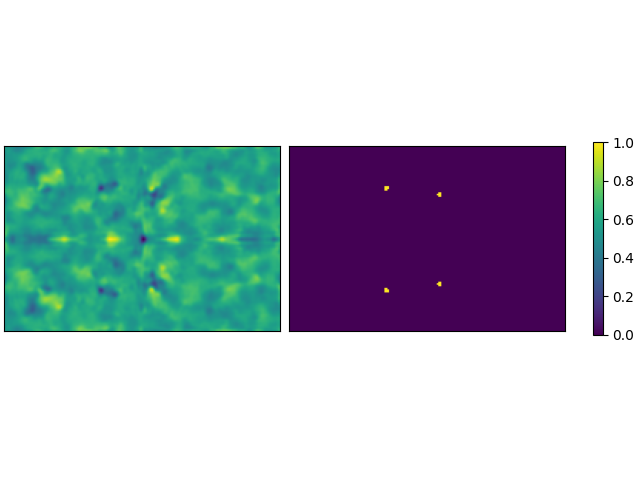

NameError: name 'make_folder_name' is not defined

In [ ]:
from plotting3d import slice_3d, panels_3d
# _ = slice_3d()

from background_matching import make_mask_from_blobs
# params = dict(blocking_radius = 3, sigma =3, min_blob_size = 1 )
mask_np = make_mask_from_blobs(diffmap, parameters, map_dark.cell, info_container)

_ = panels_3d([diffmap.to_3d_numpy_map(map_sampling =3),mask_np])
# from reciprocalspaceship.io.ccp4map import write_ccp4_map
# parameters=make_folder_name(info_container, parameters)
# fname = parameters["folder"] + "OLPVR1_mask.ccp4"
# write_ccp4_map(mask_np, fname, map_dark.cell, map_dark.spacegroup)

2026-02-27 13:45:30,578: logger: INFO: Columns of xtr: Index(['F', 'PHI', 'SIGF'], dtype='object') (background_matching.py:2080)
2026-02-27 13:45:30,588: logger: INFO: Saving xtr map: 0.10, to /Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/../xtr_map_overview/esther_10ns/esther_10ns_xxx_very_difficult_xtr0.10.mtz (background_matching.py:2087)
2026-02-27 13:45:30,602: logger: INFO: Columns of xtr_map: Index(['F', 'PHI', 'SIGF'], dtype='object') (background_matching.py:2100)
2026-02-27 13:45:30,603: logger: INFO: Columns of ds_temp: Index(['F', 'PHI', 'SIGF'], dtype='object') (background_matching.py:2101)
2026-02-27 13:45:30,652: logger: INFO: Columns of xtr: Index(['F', 'PHI', 'SIGF'], dtype='object') (background_matching.py:2080)
2026-02-27 13:45:30,662: logger: INFO: Saving xtr map: 0.18, to /Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/../xtr_map_overview/esther_10us/esther_10us_xxx_estimate_largest_xtr0.18.mtz (background_matching.py:2087)
2026-02-27 1

In [ ]:
tenate([np.arange(5,20,2.5), np.arange(20,40,5), np.arange(50, 80,10)])
xtr_factor = 25
# for xtr_factor in ranges:
save_extrapolated_map(
    info_container, 
    xtr_factor,
    map_dark,
    diffmap, 
    folder=parameters["folder"],
    name_prefix= parameters["xtr_prefix"] 
)

fname = parameters["folder"] + parameters["xtr_prefix"]+ "_diff.mtz"
diffmap.write_mtz(fname)

1/0.04, 1/0.08

V2

In [ ]:
import gemmi
from meteor.sfcalc import gemmi_structure_to_calculated_map
from meteor.scale import scale_maps
from meteorize import get_meta_loc
from meteorize import calculate_diffmaps
from meteorize import load_homepath
homepath = load_homepath()
folderloc = homepath + "../data/taher/"
dataloc_dark = folderloc + "taher-apo_dimple.mtz"
dataloc_light = folderloc + "taher-zn_dimple.mtz"
pdbloc_dark = folderloc + "TaHeR_apo_refine_3.pdb"
dark_columns = dict(
    amplitude_column="F",
    phase_column="PHIC",
    uncertainty_column="SIGF",
)
light_columns = dict(
    amplitude_column="F",
    phase_column="PHI_dark",
    uncertainty_column="SIGF",
)
fname = "taherV3"
info_container = {
    "dataloc_dark": dataloc_dark,
    "dataloc_light": dataloc_light,
    "pdbloc_dark": pdbloc_dark,
    "dark_columns": dark_columns,
    "light_columns": light_columns,
    "dark_cols": dark_columns,
    "light_cols": light_columns,
    "datatype": "ECH",
    "fname": fname,
    "tname": fname,
    "fshort": fname,
    "dark_phases": True,
    "FreeR_col": "R-free-flags"
}

rs.read_mtz(dataloc_dark)
ds_dark = rs.read_mtz(dataloc_dark)
print(ds_dark.columns)
map_dark = rsmap.Map(ds_dark, **dark_columns)

ds_light = rs.read_mtz(dataloc_light)
print(ds_light.columns)
ds_light["PHI_dark"] = map_dark.phases
map_light = rsmap.Map(ds_light, **light_columns)

dmin = np.round(ds_light.compute_dHKL()["dHKL"].min(),1)
print(f"Data resolution: {dmin} Å")
info_container["hs_limit"] = dmin

struc = gemmi.read_pdb(info_container["pdbloc_dark"])
map_dark_comp = gemmi_structure_to_calculated_map(
    struc, high_resolution_limit=info_container["hs_limit"]
)

map_dark = scale_maps(reference_map=map_dark_comp, map_to_scale=map_dark)
map_light = scale_maps(reference_map=map_dark_comp, map_to_scale=map_light)
map_light.cell = map_dark.cell
print(f"Cutting maps to {dmin} Å resolution")
map_dark = cut_resolution(map_dark, high_resolution_limit=dmin)

parameters = dict(get_tv=True, get_kweighted=False, tv_weight=2.73e-2, k_weight=0.18)
meta_loc = get_meta_loc(info_container)

diffmap = calculate_diffmaps(
        map_light, map_dark, map_dark_comp, meta_loc, only_kweighted=False, 
    )
if parameters.get("get_kweighted", False):
    diffmap = calculate_diffmaps(
        map_dark, map_light, map_dark_comp, meta_loc, only_kweighted=True
    )
elif parameters.get("get_tv", False):
    diffmap = calculate_diffmaps(
        map_dark, map_light, map_dark_comp, meta_loc, only_kweighted=False, 
    )
elif parameters.get("tv_weight", False):
    print("Using provided TV weight and K weight to calculate diffmap")
    diffmap = calculate_diffmaps(
        map_dark, map_light, map_dark_comp, meta_loc, parameters=parameters
    )

else:
    diffmap = compute_difference_map(derivative=map_light, native=map_dark)



Index(['FreeR_flag', 'F', 'SIGF', 'FC', 'PHIC', 'FC_ALL', 'PHIC_ALL', 'FWT',
       'PHWT', 'DELFWT', 'PHDELWT', 'FOM', 'FC_ALL_LS', 'PHIC_ALL_LS'],
      dtype='object')
Index(['FreeR_flag', 'F', 'SIGF', 'FC', 'PHIC', 'FC_ALL', 'PHIC_ALL', 'FWT',
       'PHWT', 'DELFWT', 'PHDELWT', 'FOM', 'FC_ALL_LS', 'PHIC_ALL_LS'],
      dtype='object')
Data resolution: 2.0 Å


2025-12-02 14:13:24,682: meteorize: INFO: this is calculate_again False (<string>:4)


Cutting maps to 2.0 Å resolution
2025-12-02 14:13:24 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2025-12-02 14:13:25 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2025-12-02 14:13:25 [info     ] Computing difference map.     
2025-12-02 14:13:58 [info     ]   using negentropy max.        kparameter=0.0
2025-12-02 14:13:58 [info     ] Searching for max-negentropy TV denoising weight method='golden-section search'
2025-12-02 14:13:58 [info     ] This may take some time...    
2025-12-02 14:14:32 [info     ] Optimal TV weight found        final_negentropy=3.56e-01 initial_negentropy=1.12e-02 weight=4.08e-02


2025-12-02 14:14:32,764: meteorize: INFO: diffmap has uncertainties: True (<string>:34)
2025-12-02 14:14:32,766: meteorize: INFO: this is calculate_again True (<string>:4)
2025-12-02 14:14:32,767: meteorize: INFO: loading: 0.0, tv_weight: 0.040840757026867035, only_kweighted: False (<string>:17)


2025-12-02 14:14:33 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2025-12-02 14:14:33 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2025-12-02 14:14:33 [info     ] Computing difference map.     
2025-12-02 14:14:33 [info     ]   using fixed                  kparameter=0.0
2025-12-02 14:14:33 [info     ] TV denoising with fixed weight weight=0.040840757026867035
2025-12-02 14:14:36 [info     ] Map TV-denoised with fixed weight final_negentropy=3.56e-01 initial_negentropy=1.12e-02 weight=0.040840757026867035


2025-12-02 14:14:36,819: meteorize: INFO: diffmap has uncertainties: True (<string>:34)


In [ ]:
from background_matching import make_folder_name, save_extrapolated_map, save_to_folder

parameters=make_folder_name(info_container, parameters)
# for xtr_factor in np.arange(1, 3.5, 0.5):
ranges = np.concatenate([np.arange(5,20,2.5), np.arange(20,40,5), np.arange(50, 80,10)])
xtr_factor = 20
# for xtr_factor in ranges:
# save_extrapolated_map(
#     info_container, 
#     xtr_factor,
#     map_dark,
#     diffmap, 
#     folder=parameters["folder"],
#     name_prefix= parameters["xtr_prefix"] 
# )

# fname = parameters["folder"] + parameters["xtr_prefix"]+ "_diff.mtz"
# diffmap.write_mtz(fname)
save_dict = dict(a = 17)
save_to_folder(diffmap, map_dark, parameters, info_container, save_dict)

2025-11-27 15:16:50,881: logger: INFO: Columns of xtr: Index(['F', 'PHI', 'SIGF'], dtype='object') (<string>:5)
2025-11-27 15:16:50,881: logger: INFO: Saving xtr map: 17.00, to /Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/../xtr_map_overview/OLVPR1_V2/OLVPR1_V2_tv_a_xtr17.00.mtz (<string>:8)
2025-11-27 15:16:50,891: logger: INFO: Columns of xtr_map: Index(['F', 'PHI', 'SIGF'], dtype='object') (<string>:18)
2025-11-27 15:16:50,892: logger: INFO: Columns of ds_temp: Index(['F', 'PHI', 'SIGF', 'R-free-flags'], dtype='object') (<string>:19)


2025-11-27 12:06:02,255: meteorize: WARNING: Used threshold for posmask: 0.145, found 642 blobs (meteorize.py:704)
2025-11-27 12:06:02,266: logger: INFO: Using blobs with more than 13.437109194872525(4 A^3) voxels (background_matching.py:527)
2025-11-27 12:06:02,266: logger: INFO: Maximum Blob sizes found: 310 (background_matching.py:530)
2025-11-27 12:06:02,328: logger: INFO: Applying blocking radius of 1.6 A around positive density regions creating a mask of shape (7, 7, 7), excluding a total of 57 voxels (control via 'blocking_radius' parameter) (background_matching.py:552)
2025-11-27 12:06:02,422: logger: INFO: Excluding 4270 (24.68%) voxels from mask due to positive density within 1.6 A (control via 'blocking_radius' parameter) (background_matching.py:570)
2025-11-27 12:06:02,444: logger: INFO: Excluding an addtional 1192 voxels from mask due to being in solvent (deactivate via 'exclude_solvent' parameter) (background_matching.py:581)
/var/folders/pr/w1s1g8813qn100g39nl2z99m0000gp

interactive(children=(IntSlider(value=72, description='f0', max=143), Output()), _dom_classes=('widget-interac…

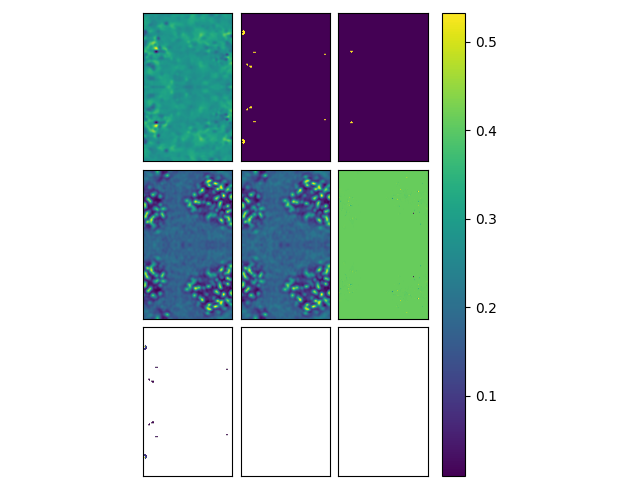

In [ ]:

from plotting3d import slice_3d, panels_3d
# _ = slice_3d()

from background_matching import make_mask_from_blobs, adding_maps
# params = dict(blocking_radius = 3, sigma =3, min_blob_size = 1 )
mask_np = make_mask_from_blobs(diffmap, parameters, map_dark.cell, info_container)
mask_2 = diffmap.to_3d_numpy_map(map_sampling =3)<-0.02
map_dark_np = map_dark.to_3d_numpy_map(map_sampling =3) + 0.31
diffmap_np = diffmap.to_3d_numpy_map(map_sampling =3)
xtr_factor = 15
xtr_map = adding_maps(map_dark, diffmap, factor2=xtr_factor)
fig, axs, im_list = panels_3d([diffmap_np ,mask_np, mask_2,map_dark_np, xtr_map.to_3d_numpy_map(map_sampling =3),
              -diffmap_np/map_dark_np,
              -diffmap_np/map_dark_np / mask_np
                ], return_ims=True)
im_list[-1].set_clim(vmin=0,vmax=0.1)
im_list[-2].set_clim(vmin=0,vmax=.1)

In [ ]:
for ax in axs.flat:
    ax.set_xlim(10,30)
    ax.set_ylim(30,50)
# from reciprocalspaceship.io.ccp4map import write_ccp4_map
# parameters=make_folder_name(info_container, parameters)
# fname = parameters["folder"] + "OLPVR1_mask.ccp4"
# write_ccp4_map(mask_np, fname, map_dark.cell, map_dark.spacegroup)

In [ ]:
1/0.05

20.0

In [ ]:
from background_matching import make_folder_name, adding_maps
filename = info_container["dataloc_dark"]
dark_columns = info_container["dark_columns"]
parameters=make_folder_name(info_container, parameters)
print(dark_columns)
loc = parameters["folder"] + "test.mtz"
ds_mtz = rs.read_mtz(filename)
ds_mtz2 = rs.read_mtz(info_container["dataloc_light"])
print(ds_mtz.columns)
meteor_map2 = rsmap.Map(ds_mtz, **dark_columns)
# meteor_map3 = rsmap.Map(ds_mtz2, **info_container["light_cols"])

meteor_map = adding_maps(meteor_map2, diffmap, factor2=20)
# mask = np.logical_or((~meteor_map["F"].isna() & meteor_map["SIGF"].isna()), (meteor_map["F"].isna() & ~meteor_map["SIGF"].isna()))
# common_indices = meteor_map2.index.intersection(diffmap.index)
# print(diffmap.loc[common_indices].loc[(np.array(mask))])
# non_matching_indices = np.sum(np.array(mask))
# if non_matching_indices > 0:
#     print(non_matching_indices)
#     logger.warning(f"Number of rows with not shared NaNs in F and SIGF: {non_matching_indices}")
meteor_map.write_mtz(loc)
meteor_map.head(20)
meteor_ds = rs.DataSet(meteor_map)
meteor_ds["R-free-flags"] = ds_mtz["R-free-flags"]
meteor_ds.write_mtz(loc)


2025-11-28 17:18:13,308: meteorize: INFO: Adding maps with high resolution limit: 2.50. (<string>:13)


{'amplitude_column': 'F-obs-filtered', 'phase_column': 'PHIF-model', 'uncertainty_column': 'SIGF-obs-filtered'}
Index(['I-obs', 'SIGI-obs', 'R-free-flags', 'F-obs-filtered',
       'SIGF-obs-filtered', 'F-model', 'PHIF-model', '2FOFCWT', 'PH2FOFCWT',
       '2FOFCWT_no_fill', 'PH2FOFCWT_no_fill', 'FOFCWT', 'PHFOFCWT'],
      dtype='object')
